## Building Multi-Agent AI System Usisng LangGraph and LangSmith

**LangGrap**: It is a library designed to build stateful, multi-actor applications with LLMs, chains and tools. It extends LangChain by allowing you to define sequences of calls (chains) more robustly, with cycles, conditional logic, and the ability to manage complex state transitions. This makes it ideal for creating agentic workflows where multiple thinking and acting steps are required, or where different specialized agents need to collaborate


### Our Customort Support Scenario
We will stimulate a realistic customer support example for a digital music store. The agent will interact with the Chinook Dataset, which contains comprehensive info about customers, ivoices, and a music catalog.

Our final architecture will look something like this:
![Multi-agent architecture](images/multi-agent-architecture.png)

As you can see, the system starts with **a customer verification** step (human-in-the-loop), then **loads user preferences** from long-term memory. A **supervisor agent** then intelligently routes the query to the appropriate specialized sub-agent: either **music catalog sub-agent** or the **invoice information sub-agent**. Finally, the system **saves any new user preferences** to long-term memory before providng a response.

#### Pre-work: Setting up the environment 

Before we dive into building our multi-agent system, let's set up our environment. We'll be using OpenAI's models in this example, but LangGraph is model-agnostic, so you can easily swap ChatOpenAI with other ChatModel providers like Azure OpenAI, Anthropic, or Google Gemini.

In [78]:
from dotenv import load_dotenv  # import func to load environment variables
from langchain_openai import ChatOpenAI
from langsmith import utils

# Load env varuables from .env file. The 'override=True' argument
load_dotenv(dotenv_path=".env", override=True)

# api_key = os.getenv('OPENAI_API_KEY')
# api_base = os.getenv('OPENAI_API_BASE')


# Initialize the ChatOpenAI mode. We'r using a specific model from Llama 3.3 series.
# This `model` object will be used throughout the notebook for all LLM interactions
llm = ChatOpenAI(model_name="inclusionai/ling-3.0-flash-fin:free", temperature=0)

#### Choosing our Dataset: 

- Here we are choosing Chinook Dataset, which is popular sample dataset used for learning and testing SQL
- It contains a digital music store's data and operations, such as customer info, purchase history & music catalog
- It comes in multiple formats like MySQL, PostgreSQL etc.. But here I'm using SQLite version of the data

Let's define a function that will set up the SQLite database for us

In [79]:
import sqlite3
import requests
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

def get_engine_for_chinook_db():
    """
    Pull SQL file, populate in-memory database, and create engine,

    Downloads the Chinook dataset SQL script from GitHub and creates an in-memory
    SQLite database populated with sample data.

    Returns:
        sqlalchemy.engine.Engine: SQLAlchemy engine connected to the in-memory database
    """

    # URL to the raw SQL script content from the URL
    url = 'https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql'

    # Fetch the SQL script content from the url
    response = requests.get(url)
    sql_script = response.text

    # Create an in-memory SQLite database connection
    # `check_same_thread=False` is important for SQLAlchemy's StaticPool
    connection = sqlite3.connect(":memory:", check_same_thread=False)

    # Execute the SQL script to populate the in-memory database with Chinook data
    connection.executescript(sql_script)

    # create a SQLAlchemy engine for in-memory SQLite database
    # `creator=lambda: connection` tells Alchemy how to get a new connection
    # `poolclass=StaticPool` is used for in-memory databases, ensuring the same connection is reused
    # `connect_args` are passes directly to the `sqlite3.connect` function
    return create_engine(
        "sqlite://",    
        creator=lambda: connection,  
        poolclass=StaticPool,   
        connect_args={'check_same_thread': False},  
    )

# Get the SQLAlchemy engine for our chinook database
engine = get_engine_for_chinook_db()


# create a LangChain SQLDatabase utility instance from the engine
# This utility will help our agents interact with the database via SQL queries
db = SQLDatabase(engine)

- So we just defined our 1st function, get_engine_for_chinook_db(), which sets up a temporary in-memory SQLite database using the Chinook sample dataset
- It downloads the SQL script from GitHub, creates the database in memory, runs the script to populate it with tables and data, and then returns a SQLAlchemy engine connected to this database


#### Setting up Short-Term and Long-Term Memory

In LangGraph, we differentiate b/w short-term memory and long-term memory. Here is a quick diff:

- **Short-term Memory (Checkpointer)**: helps an agent keep track of the current conversation. In LangGraph, this is handled by a **MemorySaver**, which saves and resumes the state of the conversation.
- **Long-tern Memory (InMemoryStore)**: lets the agent remeber info across different conversations, like user preferences. For ex: we can use an **InMemoryStore** for quick storage, but in real apps, you'd use a more permanent database


In [80]:
from langgraph.checkpoint.memory import MemorySaver     # for short-term
from langgraph.store.memory import InMemoryStore        # for long-term

# Initialize long-term memory store for persistent data b/w conversations
in_memory_store = InMemoryStore()

# Initialize checkpointer for short-term memory within a single thread/conversation
checkpointer = MemorySaver()

#### Our Multi-Agent Architecture

- We will start with ReAct agent and additional steps into the workflow, simulating a realistic customer support ex, showcasing human-in-the-loop, long term memory, and LangGraph pre-built library


Our workflow starts with:
- 1. **human_input**: where the user provides account info
- 2. Then, in **verify_info**, the system checks the account and clarifies the user's intent if needed.
- 3. Next, **load_memory** retrieve's the user's music preferences
- 4. The **supervisor** coordinates 2 sub-agents: **music_catalog** (for music data) and **invoice_info** (for billing)
- 5. Finally, **create_memory** updates the user's memory with new info from the interaction

In [81]:
print(db.get_table_info())
print(db.get_usable_table_names())


CREATE TABLE "Album" (
	"AlbumId" INTEGER NOT NULL, 
	"Title" NVARCHAR(160) NOT NULL, 
	"ArtistId" INTEGER NOT NULL, 
	PRIMARY KEY ("AlbumId"), 
	FOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")
)

/*
3 rows from Album table:
AlbumId	Title	ArtistId
1	For Those About To Rock We Salute You	1
2	Balls to the Wall	2
3	Restless and Wild	2
*/


CREATE TABLE "Artist" (
	"ArtistId" INTEGER NOT NULL, 
	"Name" NVARCHAR(120), 
	PRIMARY KEY ("ArtistId")
)

/*
3 rows from Artist table:
ArtistId	Name
1	AC/DC
2	Accept
3	Aerosmith
*/


CREATE TABLE "Customer" (
	"CustomerId" INTEGER NOT NULL, 
	"FirstName" NVARCHAR(40) NOT NULL, 
	"LastName" NVARCHAR(20) NOT NULL, 
	"Company" NVARCHAR(80), 
	"Address" NVARCHAR(70), 
	"City" NVARCHAR(40), 
	"State" NVARCHAR(40), 
	"Country" NVARCHAR(40), 
	"PostalCode" NVARCHAR(10), 
	"Phone" NVARCHAR(24), 
	"Fax" NVARCHAR(24), 
	"Email" NVARCHAR(60) NOT NULL, 
	"SupportRepId" INTEGER, 
	PRIMARY KEY ("CustomerId"), 
	FOREIGN KEY("SupportRepId") REFERENCES "Empl

## Part 1: Building ReAct Sub-Agents

Our multi-agent system will be composed of specialized sub-agents. We'll start by building two foundational ReAct agents, one from scratch to understand the core components, and another using LangGraph's pre-built utilities for quicker development.

### 1.1 Building a ReAct Agent from Scratch: The Music Catalog Sub-Agent

Our first sub-agent will be dedicated to handling customer queries related to the music catalog. This agent will utilize a set of tools to fetch information about albums, artists, tracks, and genres from the Chinook database.

The ReAct (Reasoning and Acting) framework is a popular pattern for building agents that interleave reasoning steps with acting steps (tool usage). The agent reasons about what tool to use and acts by calling that tool, then observes the result to reason again.

#### State:

In LangGraph, the **State** is a critical concept. It acts as the shared memory of the agent, a datastructure that is passed b/w the nodes of your graph, perform its logic, and return updates to the state, which then becomes the input for the next node. This continuous flow of information through the state allows the graph to maintain context and build up info as it progresses.

For our customer support agent, the state will track the following key elements:

1. customer_id: A str representation the ID of the customer interacting with agent. This is crucial for personalized queries (e.g., checking invoice history)
2. messages: An annotated list of AnyMessage objects. This forms the conversation history, including user inputs, agent responses, and tool outputs. add_messages ensures the new messages are appended to the list, maintaining the conversational flow.
3. loaded_memory: A str that will hold any user preferences or relevant info loaded from the long-term memory store. This allows the agent to tailor responses based on past interactions.
4. remaining_steps: A RemainingSteps object. This is part of LangGraph's managed state and helps track the number of steps left before a recursion limit is hit, preventing infinte loops in cyclic graphs.

In [82]:
from typing_extensions import TypedDict     # For defining dictionaries with type hints
from typing import Annotated, List          # For type hinting and adding annotations
from langgraph.graph.message import AnyMessage, add_messages    # For managing messages in the graph state
from langgraph.managed.is_last_step import RemainingSteps       # For tracking recursion limits


class State(TypedDict):
    """
    State schema for the multi-agent customer support workflow

    This defines the shared data structure that flows between nodes in the graph, 
    representing the current snapshot of the conversation and agent state.
    """

    # Customer identifier retrived from the account verification
    customer_id: str

    # Conv history with automatic message aggregation
    messages: Annotated[List[AnyMessage], add_messages]

    # User preferences & context loaded from long-term memory store
    loaded_memory: str

    # Counter to prevent infinte recursion in agent workflow
    remaining_steps: RemainingSteps

#### Tools

Tools are external functionalities that an LLM can invoke to extend its capabilities beyond pure text generation. These can be APIs, database queries, or any orbitary python functions. In our music catalog sub-agent, we'll define a set of tools that interact with the Chinnok database to fetch music-related info.

We use LangChain's @tool decorator to easily expose python functions as tools that our LLM can learn to use. The decorator automatically generates a schema that the LLM can understand, allowing it to determine when and how to call the tool.

In [83]:
from langchain_core.tools import tool
import ast

@tool
def get_albums_by_artist(artist: str):
    """Get albums by an artist"""
    # Execute a SQL query to retrieve album titles and artist names
    # from the Album and Artist tables, joining them and filtering by artist name.
    # `db.run` is a utility from LangChain's SQLDatabase to execute queries.
    # `include_columns=True` ensures column names are included in the result for better readability.

    return db.run(
        f""" 
        SELECT Album.Title, Artist.Name
        FROM Album
        JOIN Artist ON Album.ArtistId = Artist.ArtistId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True
    )

@tool
def get_tracks_by_artist(artist: str):
    """Get songs/tracks by an artist (or similar artists)"""

    # Execute a SQL query to find tracks (songs) by a given artist, or similar artists.
    # It joins Album, Artist, and Track tables to get song names and artist names.

    return db.run(
        f""" 
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True
    )

@tool
def get_songs_by_genre(genre: str):
    """
    Fetch songs from the database that match a specific genre.

    Args:
        genre (str): The genre of the songs to fetch

    Returns:
        list[dict]: A list of songs that match the specified genre.
    """

    # First, get the genre ID(s) for the specified genre
    genre_id_query = f"SELECT GenreId FROM Genre WHERE Name LIKE '%{genre}%'"
    genre_ids = db.run(genre_id_query)

    # If no genre IDs are found, return an informative message.
    if not genre_ids:
        return f"No songs found for the genre: {genre}"

    # Parse the genre IDs and format them for the SQL query
    genre_ids = ast.literal_eval(genre_ids)
    genre_id_list = ", ".join(str(gid[0]) for gid in genre_ids)

    # Query for songs in the specified genre(s)
    songs_query = f""" 
    SELECT Track.Name as SongName, Artist.Name as ArtistName
    FROM Track
    LEFT JOIN Album ON Track.AlbumId = Album.AlbumId
    LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
    WHERE Track.GenreId IN ({genre_id_list})
    GROUP BY Artist.Name
    LIMIT 8
    """

    songs = db.run(songs_query, include_columns=True)

    # Check if any songs were found
    if not songs:
        return f"No songs found for the genre: {genre}"

    # Format the results into a structured list of dictionaries
    formatted_songs = ast.literal_eval(songs)
    return [
        {"Song": song['SongName'], 'Artist': song['ArtistName']}
        for song in formatted_songs
    ]

@tool
def check_for_songs(song_title):
    """Check if a song exists by its name"""

    return db.run(
        f""" 
        SELECT * from Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True
    )

# Aggregate all music related tools into a list 
music_tools = [get_albums_by_artist, get_tracks_by_artist, get_songs_by_genre, check_for_songs]

# Bind the music tools to the LLM for use in the ReAct agent
llm_with_music_tools = llm.bind_tools(music_tools)

- get_albums_by_artist: To find albums by a given artist
- get_tracks_by_artist: To find individual songs by an artist
- get_songs_by_genre: To retrieve songs belonging to a specific genre
- check_for_songs: To verify if a particular song exists in the catalog

#### Nodes

In LangGraph, Nodes are the fundamental building blocks of your graph. They are essentially Python functions (or JS/TS functions) that take the graph's State as input, perform some logic (e.g., invoke an LLM, call a tool, update data), and return updates to the State.

For our ReAct agent, we'll deine 2 primary types of nodes:

1. **music_assistant (Reasoning Node)**: This node is an LLM responsible for reasoning. It takes the current conversation history(context) and user query, consider the available tools, and decides the next best action. This could be to invoke a tool, or if the query is satisfied, to generate a final response.
2. **music_tool_node (Action Node)**: This node is responsible for acting. When the music assistant decides to use a tool, the music_tool_node recieves the tool call, executes the specified tool function, and then return the tool's output back to the graph state. LangGraph provides a convenient ToolNode utility that automatically handles the execution of tools.

In [84]:
from langgraph.prebuilt import ToolNode     # Pre-built node for executing tools

# Create a ToolNode instance. This node will automatically execute any tool calls
# generated by an LLM that is bound to these tools
music_tool_node = ToolNode(music_tools)

In [85]:
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage    # Message types for conversation history
from langchain_core.runnables import RunnableConfig

# Define the system prompt for the music assistant
# This prompt provides instructions and persona for the LLM
# It emphasizes the agent's role, core responsibilities and search guidelines
# The  `memory` placeholder allows us to inject user preferences from long-term memory
def generate_music_assistant_prompt(memory: str='None'):
    return f""" 
    You are a member of the assistant team, your role specifically is to focused on helping customers discover and learn 
    about music in our digital catalog.
    If you are unables to find playlists, songs, or albums associated with an artist, it is okay.
    Just inform the customer that the catalog does not have any playlists, songs, or albums associated with that artist.
    You also have context on any saved user preferences, helping you to tailor your response.

    CORE RESPONSIBILITIES:
    - Search and provide accurate information about songs, albums, artists, and playlists.
    - Offer relevant recommendations based on customer interests.
    - Handle music related queries with attention to detail.
    - Help customers to discover new music they might enjoy.
    - You are routed only when there are questions related to music catalog; ignore other questions.

    SEARCH GUILDLINES:
    1. Always perform thorough searches before concluding something is unavailable.
    2. If exact matches aren't found, try:
        - Checking for alternative artist names
        - Looking for similar artist names
        - Searching by partial matches
        - Checking different versions/remixes
    3. When providing song lists:
        - Include the artist name with each song
        - Mention that album when relevant
        - Note if it's part of any playlist
        - Indicate if there are multiple versions

    Additional context is provided below:

    Prior saved user preferences: {memory}

    Message history is also attached.
    """

# Define the music_assistant node function
# This function recieves the current `State` and `RunnableConfig`
def music_assistant(state: State, config: RunnableConfig):

    # Fetch the long term memory (user preferences) from the State
    # If `loaded_memory` is not present in the state, default to `None`
    memory = "None"
    if 'loaded_memory' in state:
        memory = state['loaded_memory']

    # Generate the system prompt for the music assistant, injecting the loaded memory
    music_assistant_prompt = generate_music_assistant_prompt(memory)

    # Invoke the LLM (`llm_with_music_tools`) with the system prompt and current message history
    # The LLM will decide whether to call a tool to generate a final response
    response = llm_with_music_tools.invoke([SystemMessage(music_assistant_prompt)] + state["messages"])

    # Update the state by appending the LLM's response to the `messages` list
    # The `add_messages` annotation in `State` ensures this is appended correctly
    return {"messages": [response]}

#### Edges

**Edges** are the connections b/w nodes in a LangGraph graph. They define the flow and sequence of execution within your application

- **Normal Edges**: These are deterministic, meaning they always lead from one specified node directly to another specified node. For eg, graph.add_edge("node_A", "node_B") means after node_A finishes, node_B will always execute next
- **Conditional Edges**: These provide dynamic routing capabilities. Instead of a fixed target, a conditional edge uses a function (called a 'router' or 'conditional function') that inspects the current State and returns a string corresponding to the name of the next node to visit. This allows for flexible, intelligent decision-making about the workflow's path

For our ReAct agent, we need a **conditional edge** after the music_assistant node. This edge will determine:
- If the music_assistant decided to invoke a tool, we should route to the music_tool_node to execute it
- If the music_assistant generated a final, human readable response (i.e., no tool calls), we should END the sub-agent's execution, as the query is resolved

The should_continue function implements this conditional logic:

In [86]:
# Define a conditional edge function named `should_continue`
# This function determines the next step in the graph based on LLM's response
def should_continue(state: State, config: RunnableConfig):
    # Get the list of messages from the current state
    messages = state["messages"]
    # Get the last message contains any tool calls
    last_message = messages[-1]

    # Check if the last message contains any tool calls
    # LLMs generate `tool_calls` when they decide to use a function
    if not last_message.tool_calls:
        # If there are no `tool calls`, it means the LLM has generated a final ans
        # In this case, the sub-agent's work is done, so we return "end" to signal completion
        return "end"
    # Otherwise, if there are tool calls,
    else:
        # We need to execute the tool(s). So, we return "continue" to route to the tool execution node.
        return "continue"

The should_continue function checks the last message in the State. If it includes `tool_calls`, it means the LLM wants to use a tool, so the function return `continue`

Otherwise, it returns `end`, indicating the LLM has provided a direct response and the sub-agent's task is complete.

Now that we have all the pieces, State, Nodes, and Edges

Let's assemble them to construct our complete ReAct agent using `StateGraph`

#### Compile Graph

The  `StateGraph` class is used to define the structure of our agent. We add nodes and edges, and then `compile` the graph. Compilations turns the defined graph into a runnable object, ready to be invoked.

Key Methods used:

- `StateGraph(State)`: initializes a graph with our defined state schema
- `add_node(name, node_function)`: Adds a node to the graph, assosciating a name with a callable Python function
- `add_edge(source, target)`: Creates a direct, unconditional edge from `source` node to `target` node
- `add_conditional_edges(source, condition_function, mapping)`: Creates a dynamic edge. `condition_function` is called to determine the next node based on its return values, which must match a key in the `mapping` dictionary
    - `START`: A special entry point that signifies the beginning of the graph execution
    - `END`: A special exit point that signifies the completion of the graph execution
- `compile(name, checkpointer, store)`: Finalizes the graph
    - `name`: A unique identifier for the compiled graph
    - `checkpointer`: The short-term memory mechanism (`MemorySaver`) to persist and resume graph state
    - `store`: The long-term memory mechanism (`InMemoryStore`) for data persistent across sessions

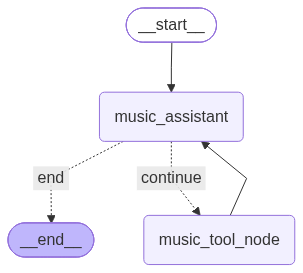

In [87]:
from langgraph.graph import StateGraph, START, END  # Core LangGraph classes and special node names
from utils import show_graph    # Utility function to visualize the graph 

# Initialize a StateGraph with our defines `State` schema
# This tells LangGraph how the data will flow and be managed and generating tool calls or final response
music_workflow = StateGraph(State)

# Add the `music_assistant` node to the graph
# This node is responsible for executing the tools when requested by LLM
music_workflow.add_node("music_assistant", music_assistant)

# Add the `music_tools_node` to the graph
# This node is responsible for executing the tools when requested by an LLM
music_workflow.add_node("music_tool_node", music_tool_node)

# Define the starting point of the graph
# All queries will initially enter the `music_assistant` node
music_workflow.add_edge(START, "music_assistant")

# Add a conditional edge from `music_assistant`
# The `should_continue` func will be caled to determine the next node
music_workflow.add_conditional_edges(
    "music_assistant",  # Source node
    should_continue,    # Conditional func to call
    {
        # If `should_continue` returns `continue`, route to `music_assistant`
        "continue": "music_tool_node",
        # If `should_continue` returns "end", terminate the graph execution
        "end": END
    }
)

# Add a normal edge from `music_tool_node` back to `music_assistant`
# After a tool is executed, the result is fed back to the LLM foris further reasoning
# or to formulate a final response (ReAct loop)
music_workflow.add_edge("music_tool_node", "music_assistant")


# Compile the graph into a runnable object
# `name`: A unique identifier for this compiled graph (useful for debugging and logging)
# `checkpointer`: The short-term memory mechanism (MemorySaver) for thread-specific state
# `store`: The long-term memory mechanism (InMemoryStore) for persistent user data
music_catalog_subagent = music_workflow.compile(name="music_catalog_subagent", checkpointer=checkpointer, store=in_memory_store)

# Display a visulaization of the compiled graph
show_graph(music_catalog_subagent)


#### Testing the Music Catalog Sub-Agent

Now that our first ReAct agent is compiled, let's test its functionality. We'll simulate inquiry and observe how the agnet processes it, potentially invoking tools and providing a response.

Key elements in testing:
- `uuid.uuid4()`: Generates a unique thread ID for each conversation. This is crucial for checkpointer to maintain seperate states for different conversations
    - In a real application, this `thread_id` would typically correspond to a user session or a unique conversation identifier.
- `config`: A dictionary passed to the `invoke` method, containing configurable params like the `thread_id`. The checkpointer uses this `thread_id` to load and save the correct state.
- `invoke()`: Starts the execution to the LangGraph. It takes the initial input (`messages` in our `State`) and the `config`
- `pretty_print()`: A utility method (assuming it's defined for `AnyMessage` or similar) to display the messages in a readable format, showing roles and content

In [88]:
import uuid     # Module for generating unique identifiers

# Generate a unique thread ID for this conv
# This ensures that the conversation state is isolated and can be resumed later
thread_id = uuid.uuid4()

# Define the customer's Q
question = "I like the Rolling Stones. What songs do you recommend by them or by other artists that I might like?"

# Create the configuration dict for invoking the graph
# The `thread_id` is essential for the checkpointer to manage state
config = {'configurable': {'thread_id': thread_id}}

# Invoke the `music_catalog_subagent` with the initial human message and configuration
# The `invoke` method runs the graph to completion and returns the final state
result = music_catalog_subagent.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Iterate through the messages in the final state and print them for observation
# `pretty_print` provides a formatted output of the message content and role
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

I like the Rolling Stones. What songs do you recommend by them or by other artists that I might like?
================================== Ai Message ==================================
Tool Calls:
  get_tracks_by_artist (call_d59abd907be94370af65613a)
 Call ID: call_d59abd907be94370af65613a
  Args:
    artist: Rolling Stones
  get_songs_by_genre (call_d561ecdc896742459cc9d074)
 Call ID: call_d561ecdc896742459cc9d074
  Args:
    genre: Classic Rock
================================= Tool Message =================================
Name: get_tracks_by_artist

[{'SongName': 'Time Is On My Side', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Heart Of Stone', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Play With Fire', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Satisfaction', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'As Tears Go By', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Ge

### 1.2 Building ReAct Agent using LangGraph Pre-built: The Invoice Information Sub-Agent

While building agents from scratch provides deep understanding, LangGraph also offers **pre-built libraries** for common architectures. These pre-built solutions allow for rapid development of standard agent pattersn like ReAct, saving significant boilerplate code.

You can find a full list of available pre-built libraries here: 

In this section, we will demonstrate how to create our second sub-agent, the **Invoice Information Sub-Agent**, using `create_react_agent` pre-built utility. This agent will be responsible for handling all customer queries related to invoices and past purchases.



#### Defining Tools and Prompt for Invoice Sub-Agent

Similar to our music sub-agent, the invoice sub-agent requires it's own set of specialized tools and tailored prompt. These tools will interact with the Chinnok database to retrive invoice-specific inffo. 
Each tool is designed to answer a specific type of query a customer might have about their invoices. The prompts will guide the LLM to understand its role and effectively use these tools.

In [108]:
from langchain_core.tools import tool   # Import the tool decorator again

@tool
def get_invoices_by_customer_sorted_by_data(customer_id: str) -> list[dict]:
    """ 
    Look up all invoices for a customer using the ID.
    The invoices are sorted in descending order by invoice date, which helps when th customer wants to view their most recent/oldest invoice, or if
    they want to view invoices within a specific date range.count

    Args:
        customer_id (str): customer_id, which serves as the identifier

    Returns:
        list[dict]: A list of invoices for the customer.
    """

    # Executes a SQL query to retreive all invoice details from a given customer ID,
    # ordered by invoice date in descending order (most recent first)
    return db.run(
        f"""SELECT * FROM Invoice
        WHERE CustomerId={customer_id}
        ORDER BY InvoiceDate DESC;"""
    )

@tool
def get_invoices_sorted_by_unit_price(customer_id: str) -> list[dict]:
    """ 
    Use this tool when the customer wants to know the details of one of their invoices based on unit price/cost
    of the invoice.
    This tool looks up all invoices for a customer, and sorts the unit price from highest to lowest. In order
    to find the invoice associated with the customer, we need to know the customer ID.
    
    Args:
        customer_id (str): customer_id, which serves as the identifier.
        
    Returns:
        list[dict]: A list of invoices sorted by unit price."""

    # Executes a SQL query to retrive invoice details along with the unit price in those invoices,
    # for a given query customer ID, ordered by unit price in descending order (highest unit price first)
    query = f""" 
            SELECT Invoice.*, InvoiceLine.UnitPrice
            FROM Invoice
            JOINE InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
            where Invoice.CustomerId={customer_id}
            order by InvoiceLine.UnitPrice DESC;"""
    
    return db.run(query)

@tool
def get_employee_by_invoice_and_customer(invoice_id: str, customer_id: str) -> dict:
    """ 
    This tool will take in an invoice ID and a customer ID and return the employee information associated with the invoice.
    
    Args:
        invoice_id (str): The ID of the specific invoice
        customer_id (str): customer_id, which serves as the identifier
        
    Returns:
        dict: Information about the employee associated with the invoice"""

    query = f""" 
            SELECT Employee.FirstName, Employee.Title, Employee.Email
            from Employee
            join Customer ON Customer.SupportRepId = Employee.EmployeeId
            join Invoice ON Invoice.CustomerId = Customer.CustomerId
            where Invoice.InvoiceId = ({invoice_id}) and Invoice.CustomerId = ({customer_id});"""

    employee_info = db.run(query)

    # Checks if any employee info was found.
    if not employee_info:
        return f"No employee found for Invoice ID {invoice_id} and customer identifier {customer_id}"
    return employee_info

# Aggregate all invoice-related tools into a list
invoice_tools = [get_invoices_by_customer_sorted_by_data, get_invoices_sorted_by_unit_price, get_employee_by_invoice_and_customer]

In [98]:
# Define the system prompt for the invoice information sub-agent.
# This prompt sets the persona and core responsibilities for the LLM within this sub-agent's domain.
# It explicitly lists the tools available to this agent and provides guidelines for their use.

invoice_subagent_prompt = f""" 
    You are a subagent among a team of assistants. You are specialized for retrieving and processing invoice information. You
    are routed for invoice-related queries, so only respond to them.

    You have access to three tools. These tools enable you to retrive and process invoice information from the database. Here are tools:
    - get_invoices_by_customer_sorted_by_date: This tool retreives all invoices for a customer, sorted by invoice date
    - get_invoices_sorted_by_unit_price: This tool retrieves all invoices for a customer, sorted by unit price
    - get_employee_by_invoice_and_customer: This tool retrieves the employee information associated with an invoice and customer.

    If you are unable to retrieve the invoice information, inform the customer you are unable to retrieve the information, and ask
    if they would like to search for something else.

    CORE_RESPONSIBILITIES:
    - Retrieve and process invoice information from the database
    - Provide detailed information about invoices, including customer details, invoices dates, total amounts, employee associated with the invoice,
    etc,.. when the customer asks for it.
    - Always maintain a professional, friendly, and patient demeanor

    You may have additional context that you should use to help answer the customer's query. It will be provided to to you below:
    """

#### Using the pre-built library: `create_react_agent`

Now let's assemble our invoice sub-agent using LangGraph's `create_react_agent` function. This utility abstracts away the node and edge
definitions for a standard ReAct loop, allowing us to quickly create a runnable agent.

The `create_react_agent` function handles:

- Binding the provided `tools` to the model
- Setting up the LLM(`model`) as the reasoning node
- Setting up a `ToolNode` to execute the tools
- Defining the conditional logic (edges) to loop b/w the LLM and the tools until a final ans is produced or a recursion limit is reached

We provide it with:

- `model`: The LLM to use (llm instance)
- `tools`: The list of functions avail to the agent
- `name`: A unique name for this agent (useful for identification in a multi-agent system)
- `prompt`: The system prompt to guide the LLM's behavior
- `state_schema`: The `State` class we defines, ensuring consistency across agents
- `checkpointer` and `store`: Our memory mechanisms for thread-level state and long-term user data

In [109]:
from langgraph.prebuilt import create_react_agent   # Import pre-built ReAct agent creator

# Define the invoice information subagent using the pre-built `create_react_agent`.
# This function internally sets up the nodes (LLM and ToolNode) and edges for a ReAct loop.
invoice_information_subagent = create_react_agent(
    llm,
    tools=invoice_tools,
    name="invoice_information_subagent",
    prompt=invoice_subagent_prompt,
    state_schema=State,
    checkpointer=checkpointer,
    store=in_memory_store
)


/var/folders/rb/6sw_x3g548l9wq12c8d0fhvm0000gn/T/ipykernel_89386/3582853078.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  invoice_information_subagent = create_react_agent(


#### Testing the Invoice Information Sub-Agent

Let's test our newly created invoice sub-agent to ensure it correctly processes queries related to invoices

In [110]:
thread_id = uuid.uuid4()    # Generate a new unique thread ID for this test conv

# Define a sample question for the invoice sub-agent
question = "My customer id is 1. What was my most recent invoice, and who was the employee that helped me with it?"

config = {"configurable": {"thread_id": thread_id}}

result = invoice_information_subagent.invoke({"messages": HumanMessage(content=question)}, config=config)

for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

My customer id is 1. What was my most recent invoice, and who was the employee that helped me with it?
================================== Ai Message ==================================
Name: invoice_information_subagent
Tool Calls:
  get_invoices_by_customer_sorted_by_data (call_b48d637ed3f447cf82fc19ce)
 Call ID: call_b48d637ed3f447cf82fc19ce
  Args:
    customer_id: 1
================================= Tool Message =================================
Name: get_invoices_by_customer_sorted_by_data

[(382, 1, '2025-08-07 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 8.91), (327, 1, '2024-12-07 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 13.86), (316, 1, '2024-10-27 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 1.98), (195, 1, '2023-05-06 00:00:00', 'Av. B

## Part 2: Building Multi-Agent Architecture (Supervisor)

Now that we have two specialized sub-agents—one for music catalog inquiries and another for invoice information—the next logical step is to ensure that customer queries are routed to the appropriate agent. This is where a supervisor agent comes into play.

The supervisor acts as a central coordinator, overseeing the workflow and intelligently invoking the most relevant sub-agent based on the customer's query. This eliminates the need for each sub-agent to understand all possible query types, allowing them to remain focused on their core expertise.

### The Supervisor Role:


The supervisor' primary responsibilities include:

- **Intent Recognition**: Analyzing the incoming customer query to determine its primary intent (e.g., music-related, invoice-related or sth else)
    - `music_catalog_information_subagent`: Handles queries about songs, albums, artists, genres, and music preferences.
    - `invoice_information_subagent`: Handles queries about past purchases, invoices, and billing details.
- **Routing**: Directing the query to the appropriate specialized sub-agent on the recognized intent
- **Orchestration (Implicit)**: While the supervisor explicitly routes, it implicitly orchestrates by ensuring the right aagent is active at the right time. For multi-turn conversations, it might re-route or allow the current sub-agent to continue

LangGraph offers a pre-built `create_supervisor` utility, which simplifies the creation of such a routing mechansim. This function sets up a powerful LLM based router that leverages the descriptions and capabilities of the sub-agent to make routing decisions

First, we will create a set of instructions for our supervisor. This prompt defines the supervisor's persona, it's roles as a planner and router, and the capabilities of the sub-agent it overseas.

In [111]:
supervisor_prompt = """ 
You are an expert customer support assistant for a digital music store. 
You are dedicated to providing exceptional service and ensuring customer queries are answered thoroughly. 
You have a team of subagents that you can use to help answer queries from customers. 
Your primary role is to serve as a supervisor/planner for this multi-agent team that helps answer queries from customers. 

Your team is composed of two subagents that you can use to help answer the customer's request:
1. music_catalog_information_subagent: this subagent has access to user's saved music preferences. It can also retrieve information about the digital music store's music 
catalog (albums, tracks, songs, etc.) from the database. 
3. invoice_information_subagent: this subagent is able to retrieve information about a customer's past purchases or invoices 
from the database. 

Based on the existing steps that have been taken in the messages, your role is to generate the next subagent that needs to be called. 
This could be one step in an inquiry that needs multiple sub-agent calls.
"""

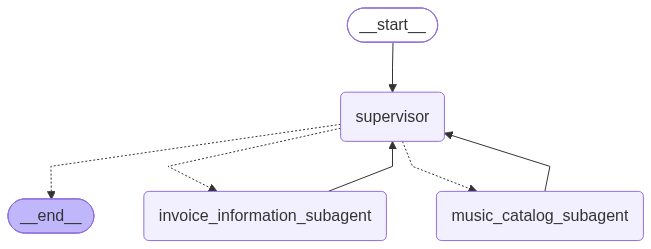

In [112]:
from langgraph_supervisor import create_supervisor  # Import the pre-built supervisor creator

# Create the supervisor workflow using the `create_supervisor` utility.
# This function dynamically sets up the graph to route between the provided agents.
supervisor_prebuilt_workflow = create_supervisor(
    agents=[invoice_information_subagent, music_catalog_subagent],
    output_mode="last_message", # Specifies that the supervisor should output only the last msg from the routed agent, Alternative is `full_history` to get all msgs from the sub-agent
    model=llm,
    prompt=(supervisor_prompt),
    state_schema=State      # The shared state schema for the entire multi-agent graph
)

# Compile the supervisor workflow into a runnable object.
# This makes it ready for invocation and integrates it with our memory systems.
supervisor_prebuilt = supervisor_prebuilt_workflow.compile(name="music_catalog_subagent", checkpointer=checkpointer, store=in_memory_store)

show_graph(supervisor_prebuilt)
